In [2]:
# Setup Notebook

In [3]:
import numpy as np
import pandas as pd

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [5]:
import os

if not os.path.exists('car_fuel_efficiency.csv'):
    !wget $data
else:
    print("File already exists — skipping download.")

File already exists — skipping download.


In [6]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [7]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [8]:
# Data Prep

In [9]:
df.columns.str.lower().str.replace(' ', '_')

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [10]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [11]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [12]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [13]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369


In [14]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [15]:
## EDA

In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[170 130 220 210 190]
36

num_cylinders
[ 3.  5. nan  4.  1.]
14

horsepower
[159.  97.  78.  nan 140.]
192

vehicle_weight
[3413.43375861 3149.66493422 3079.03899737 2542.39240183 3460.87098999]
9704

acceleration
[17.7 17.8 15.1 20.2 14.4]
162

model_year
[2003 2007 2018 2009 2008]
24

origin
['europe' 'usa' 'asia']
3

fuel_type
['gasoline' 'diesel']
2

drivetrain
['all-wheel_drive' 'front-wheel_drive']
2

num_doors
[ 0.  2. -1.  1. nan]
9

fuel_efficiency_mpg
[13.23172891 13.68821744 14.246341   16.9127356  12.48836912]
9704



In [17]:
# imports

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [18]:
df.head()


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

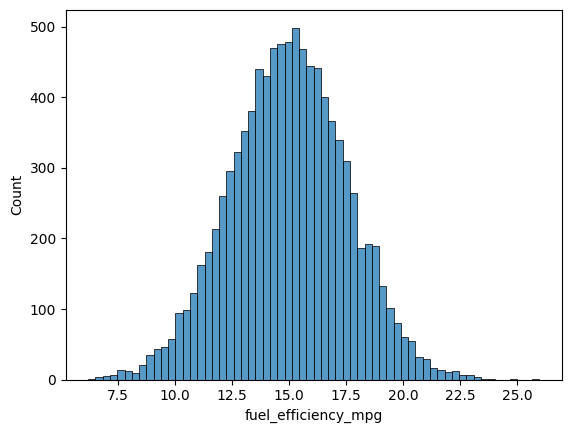

In [19]:
#sns.histplot(df['fuel_efficiency_mpg'], bins='30')
sns.histplot(df['fuel_efficiency_mpg'], bins='fd')

In [20]:
# no long tail distribution, looks like a normal distribution

In [21]:
# Q1 Missing Values

df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [22]:
# horsepower has missing values

In [44]:
# Q2 whats the median horsepower?

df['horsepower'].median()

np.float64(149.0)

In [24]:
# median is 149.0

In [25]:
# filter data set

df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


In [26]:
# Prepare and split the dataset

In [27]:
n = len(df)
n

9704

In [28]:
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

In [29]:
n, n_val + n_test + n_train

(9704, 9704)

In [30]:
n_val, n_test, n_train

(1940, 1940, 5824)

In [31]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]


In [32]:
# shuffle the data 

idx = np.arange(n)

np.random.seed(42)
np.random.shuffle(idx)

In [33]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209


In [34]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [35]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [37]:
# getting the target variable on normal distribution

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [38]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']  

In [39]:
y_train

array([16.64294342, 16.29837715, 18.59182197, ..., 17.59323665,
       18.92574819, 17.96528447], shape=(5824,))

In [42]:
print(df_train.columns)

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='object')


In [43]:
len(y_train), len(y_val), len(y_test)

(5824, 1940, 1940)

In [45]:
# Q3 

df_train.iloc[10]

engine_displacement     240.000000
horsepower              159.000000
vehicle_weight         2916.987921
model_year             2001.000000
Name: 10, dtype: float64

In [59]:
xi = [240, 159, 2916, 2001]

w0 = 0
w = [1, 1, 1, 1]

def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res += xi[j] * w[j]

    return res

def linear_regression(xi): 
    return w0 + dot(xi, w)

w_new = [w0] + w
w_new

def linear_regression(xi):
    xi = [1] + xi 
    return dot(xi, w_new)

linear_regression(xi)

w0 = 7.17
w = [.01, .04, .002, .002]
w_new = [w0] + w

x1 = [1, 240, 159, 2916, 2001]
x2 = [1, 200, 150, 2900, 2000]
x10 = [1, 300, 200, 3200, 2020]

X = [x1, x2, x10]
X = np.array(X)

def linear_regression(X):
    return X.dot(w_new)

linear_regression(X)

array([25.764, 24.97 , 28.61 ])

In [92]:
X = [
    [240, 159, 2916, 2001],
    [200, 150, 2900, 2000],
    [300, 200, 3200, 2020],
    [340, 159, 2916, 2001],
    [100, 250, 2960, 2000],
    [500, 300, 2200, 2020],
    [210, 59, 2916, 2001],
    [260, 110, 2400, 2000],
    [320, 240, 3000, 2020],
]
X = np.array(X)

ones = np.ones(X.shape[0])

X = np.column_stack ([ones, X])

y = [25, 30, 20, 19, 35, 15, 27, 32, 18]

XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)

w_full = XTX_inv.dot(X.T).dot(y)
w = w_full[1:]

w0, w



(7.17, array([-0.0728613 , -0.00459599, -0.01200055,  0.02361501]))

In [93]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:] 

In [94]:
X.shape


(9, 5)

In [67]:
df_train.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
dtype: object

In [70]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [95]:
X_train = df_train[base].values

In [96]:
train_linear_regression(X_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan]))

In [98]:
# missing values

In [107]:
# fill with 0

df_train[base].fillna(0).isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [100]:
X_train = df_train[base].fillna(0).values

In [102]:
w0, w = train_linear_regression(X_train, y_train)

In [103]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

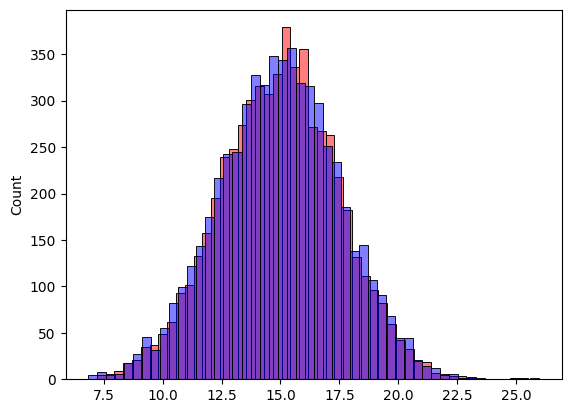

In [106]:
sns.histplot(y_pred, bins='fd', alpha=0.5, color='red') 
sns.histplot(y_train, bins='fd', alpha=0.5, color='blue')

In [ ]:
# fill with mean

X_train = df_train[base].fillna(df_train[base].mean()).values


<Axes: ylabel='Count'>

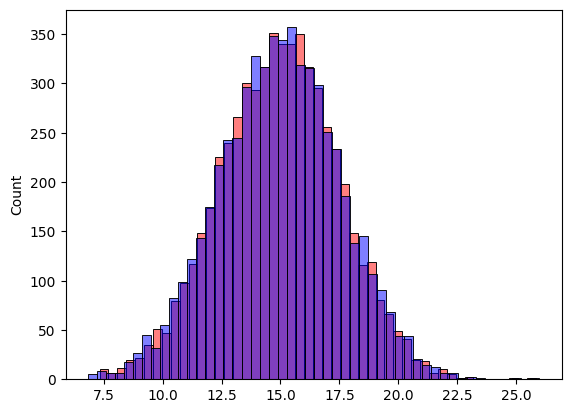

In [122]:
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)
sns.histplot(y_pred, bins='fd', alpha=0.5, color='red') 
sns.histplot(y_train, bins='fd', alpha=0.5, color='blue')

In [119]:
# filling with 0 or mean gives similar results